In [40]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import imblearn
import itertools
import sys
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn import metrics as metrics
import warnings
warnings.filterwarnings('ignore')

In [41]:
test = pd.read_csv("UNSW_NB15_testing-set.csv")
test = test.iloc[:,:-1] 

In [42]:
train = pd.read_csv("UNSW_NB15_training-set.csv")
train = train.iloc[:,:-1] 

In [43]:
def bar_graph(feature):
    train[feature].value_counts().plot(kind="bar")


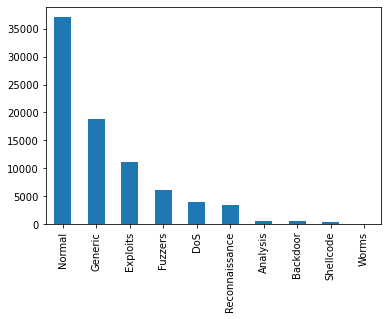

In [44]:
bar_graph('attack_cat')

In [45]:
y = train["attack_cat"].values
from collections import Counter
Counter(y)

Counter({'Normal': 37000,
         'Reconnaissance': 3496,
         'Backdoor': 583,
         'DoS': 4089,
         'Exploits': 11132,
         'Analysis': 677,
         'Fuzzers': 6062,
         'Worms': 44,
         'Shellcode': 378,
         'Generic': 18871})

In [46]:
y1 = test["attack_cat"].values
from collections import Counter
Counter(y1)

Counter({'Normal': 56000,
         'Backdoor': 1746,
         'Analysis': 2000,
         'Fuzzers': 18184,
         'Shellcode': 1133,
         'Reconnaissance': 10491,
         'Exploits': 33393,
         'DoS': 12264,
         'Worms': 130,
         'Generic': 40000})

In [47]:
from sklearn.preprocessing import LabelEncoder
encodings = dict()
for c in train.columns:
    
    if train[c].dtype == "object":
        encodings[c] = LabelEncoder()
        encodings[c]
        train[c] = encodings[c].fit_transform(train[c])

In [48]:
y = train.pop("attack_cat").values
X = train.values

In [49]:
train.dtypes

id                     int64
dur                  float64
proto                  int32
service                int32
state                  int32
spkts                  int64
dpkts                  int64
sbytes                 int64
dbytes                 int64
rate                 float64
sttl                   int64
dttl                   int64
sload                float64
dload                float64
sloss                  int64
dloss                  int64
sinpkt               float64
dinpkt               float64
sjit                 float64
djit                 float64
swin                   int64
stcpb                  int64
dtcpb                  int64
dwin                   int64
tcprtt               float64
synack               float64
ackdat               float64
smean                  int64
dmean                  int64
trans_depth            int64
response_body_len      int64
ct_srv_src             int64
ct_state_ttl           int64
ct_dst_ltm             int64
ct_src_dport_l

In [50]:
from sklearn.preprocessing import StandardScaler
X = StandardScaler().fit_transform(X)

In [51]:
"""RFE STARTS"""

'RFE STARTS'

In [52]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

rfe = RFE(estimator=RandomForestRegressor(), n_features_to_select=30)

_ = rfe.fit(X, y)

In [53]:
print(X.shape)
X_train_rfe = X[:, rfe.support_]
print(X_train_rfe.shape)

(82332, 43)
(82332, 30)


In [54]:
X_train_rfe, X_test_rfe, y_train_rfe, y_test_rfe = train_test_split(rfe.transform(X), y, test_size=0.2, random_state=42)

In [55]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

neigh = KNeighborsClassifier(n_neighbors=5,weights='uniform')
neigh.fit(X_train_rfe, y_train_rfe)

KNeighborsClassifier()

In [56]:
y_pred_rfe = neigh.predict(X_test_rfe)
print(Counter(y_pred_rfe))
print(Counter(y_test_rfe))

Counter({6: 7569, 5: 3638, 3: 2421, 4: 1200, 2: 789, 7: 625, 0: 150, 1: 42, 8: 33})
Counter({6: 7418, 5: 3723, 3: 2275, 4: 1212, 2: 786, 7: 723, 0: 131, 1: 117, 8: 75, 9: 7})


In [57]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test_rfe, y_pred_rfe) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test_rfe, y_pred_rfe))
print('Report : ')
print(classification_report(y_test_rfe, y_pred_rfe))

Confusion Matrix :
[[   9    2   22   73   24    0    1    0    0    0]
 [   5    0    7   75   25    1    3    1    0    0]
 [   9   13  307  375   34    5   16   22    5    0]
 [  81   12  337 1501  165   12   67   94    6    0]
 [  46   10   44  165  763    4  145   32    3    0]
 [   0    1   17   60   11 3611   15    8    0    0]
 [   0    0    1   18  112    4 7273    7    3    0]
 [   0    4   54  136   52    0   43  433    1    0]
 [   0    0    0   12   14    1    5   28   15    0]
 [   0    0    0    6    0    0    1    0    0    0]]
Accuracy Score : 0.8448411975466084
Report : 
              precision    recall  f1-score   support

           0       0.06      0.07      0.06       131
           1       0.00      0.00      0.00       117
           2       0.39      0.39      0.39       786
           3       0.62      0.66      0.64      2275
           4       0.64      0.63      0.63      1212
           5       0.99      0.97      0.98      3723
           6       0.96  

In [58]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(neigh, X_train_rfe, y_train_rfe, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_rfe, predicted))
print('Report : ')
print(classification_report(y_train_rfe, predicted))

Accuracy Score : 0.8435587945039095
Report : 
              precision    recall  f1-score   support

           0       0.08      0.08      0.08       546
           1       0.00      0.00      0.00       466
           2       0.39      0.38      0.39      3303
           3       0.62      0.66      0.64      8857
           4       0.61      0.62      0.62      4850
           5       0.99      0.97      0.98     15148
           6       0.96      0.98      0.97     29582
           7       0.69      0.62      0.65      2773
           8       0.45      0.13      0.20       303
           9       0.00      0.00      0.00        37

    accuracy                           0.84     65865
   macro avg       0.48      0.44      0.45     65865
weighted avg       0.84      0.84      0.84     65865



In [59]:
#SVM
from sklearn.svm import SVC

clf = SVC(gamma='auto',decision_function_shape='ovo')
clf.fit(X_train_rfe, y_train_rfe)

SVC(decision_function_shape='ovo', gamma='auto')

In [60]:
y_pred_rfe=clf.predict(X_test_rfe)
print(Counter(y_pred_rfe))
print(Counter(y_test_rfe))

Counter({6: 7692, 5: 3599, 3: 2222, 4: 1435, 2: 884, 7: 635})
Counter({6: 7418, 5: 3723, 3: 2275, 4: 1212, 2: 786, 7: 723, 0: 131, 1: 117, 8: 75, 9: 7})


In [61]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test_rfe, y_pred_rfe) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test_rfe, y_pred_rfe))
print('Report : ')
print(classification_report(y_test_rfe, y_pred_rfe))

Confusion Matrix :
[[   0    0   28   37   56    0    6    4    0    0]
 [   0    0    4   40   61    0    9    3    0    0]
 [   0    0  393  242   85    1   25   40    0    0]
 [   0    0  348 1541  202    0  121   63    0    0]
 [   0    0   43  124  872    1  139   33    0    0]
 [   0    0    4   83   11 3594   21   10    0    0]
 [   0    0    3   27   84    1 7258   45    0    0]
 [   0    0   60  111   54    2   92  404    0    0]
 [   0    0    1   12   10    0   19   33    0    0]
 [   0    0    0    5    0    0    2    0    0    0]]
Accuracy Score : 0.8539503248922087
Report : 
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       131
           1       0.00      0.00      0.00       117
           2       0.44      0.50      0.47       786
           3       0.69      0.68      0.69      2275
           4       0.61      0.72      0.66      1212
           5       1.00      0.97      0.98      3723
           6       0.94  

In [62]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train_rfe, y_train_rfe, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_rfe, predicted))
print('Report : ')
print(classification_report(y_train_rfe, predicted))

Accuracy Score : 0.8535641084035527
Report : 
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       546
           1       0.00      0.00      0.00       466
           2       0.45      0.47      0.46      3303
           3       0.68      0.68      0.68      8857
           4       0.62      0.73      0.67      4850
           5       1.00      0.96      0.98     15148
           6       0.95      0.98      0.96     29582
           7       0.63      0.58      0.61      2773
           8       0.00      0.00      0.00       303
           9       0.00      0.00      0.00        37

    accuracy                           0.85     65865
   macro avg       0.43      0.44      0.44     65865
weighted avg       0.84      0.85      0.85     65865



In [63]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(random_state=0,solver='saga',multi_class='multinomial').fit(X_train_rfe, y_train_rfe)

In [64]:
y_pred_rfe = clf.predict(X_test_rfe)
print(Counter(y_pred_rfe))
print(Counter(y_test_rfe))

Counter({6: 8390, 5: 3888, 3: 1723, 4: 984, 2: 840, 7: 642})
Counter({6: 7418, 5: 3723, 3: 2275, 4: 1212, 2: 786, 7: 723, 0: 131, 1: 117, 8: 75, 9: 7})


In [65]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
print('Accuracy Score :',accuracy_score(y_test_rfe, y_pred_rfe))
print('Report : ')
print(classification_report(y_test_rfe, y_pred_rfe))

Accuracy Score : 0.7794376632051983
Report : 
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       131
           1       0.00      0.00      0.00       117
           2       0.44      0.47      0.46       786
           3       0.56      0.42      0.48      2275
           4       0.58      0.47      0.52      1212
           5       0.93      0.97      0.95      3723
           6       0.83      0.94      0.88      7418
           7       0.55      0.49      0.52       723
           8       0.00      0.00      0.00        75
           9       0.00      0.00      0.00         7

    accuracy                           0.78     16467
   macro avg       0.39      0.38      0.38     16467
weighted avg       0.75      0.78      0.76     16467



In [66]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train_rfe, y_train_rfe, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_rfe, predicted))
print('Report : ')
print(classification_report(y_train_rfe, predicted))

Accuracy Score : 0.7821149320579974
Report : 
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       546
           1       0.00      0.00      0.00       466
           2       0.44      0.45      0.44      3303
           3       0.56      0.43      0.49      8857
           4       0.57      0.48      0.52      4850
           5       0.92      0.97      0.94     15148
           6       0.84      0.94      0.89     29582
           7       0.55      0.50      0.52      2773
           8       0.00      0.00      0.00       303
           9       0.00      0.00      0.00        37

    accuracy                           0.78     65865
   macro avg       0.39      0.38      0.38     65865
weighted avg       0.75      0.78      0.76     65865



In [67]:
#Multi Layer Perceptron
from sklearn.neural_network import MLPClassifier
clf = MLPClassifier(alpha=1)
clf.fit(X_train_rfe, y_train_rfe)
clf

MLPClassifier(alpha=1)

In [68]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test_rfe, y_pred_rfe) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test_rfe, y_pred_rfe))
print('Report : ')
print(classification_report(y_test_rfe, y_pred_rfe))

Confusion Matrix :
[[   0    0   21   23   33   26   24    4    0    0]
 [   0    0    4   22   46   27   15    3    0    0]
 [   0    0  371  175   48   47   86   59    0    0]
 [   0    0  338  958  137   98  651   93    0    0]
 [   0    0   41  120  575   61  378   37    0    0]
 [   0    0    3   46    4 3607   54    9    0    0]
 [   0    0    3  277   98   14 6972   54    0    0]
 [   0    0   58   92   35    7  179  352    0    0]
 [   0    0    1    6    8    0   29   31    0    0]
 [   0    0    0    4    0    1    2    0    0    0]]
Accuracy Score : 0.7794376632051983
Report : 
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       131
           1       0.00      0.00      0.00       117
           2       0.44      0.47      0.46       786
           3       0.56      0.42      0.48      2275
           4       0.58      0.47      0.52      1212
           5       0.93      0.97      0.95      3723
           6       0.83  

In [69]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train_rfe, y_train_rfe, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_rfe, predicted))
print('Report : ')
print(classification_report(y_train_rfe, predicted))

Accuracy Score : 0.8449252258407348
Report : 
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       546
           1       0.00      0.00      0.00       466
           2       0.45      0.32      0.37      3303
           3       0.66      0.70      0.68      8857
           4       0.57      0.71      0.63      4850
           5       0.98      0.96      0.97     15148
           6       0.95      0.97      0.96     29582
           7       0.55      0.58      0.57      2773
           8       0.00      0.00      0.00       303
           9       0.00      0.00      0.00        37

    accuracy                           0.84     65865
   macro avg       0.42      0.43      0.42     65865
weighted avg       0.83      0.84      0.84     65865



In [70]:
#RandomForest
from sklearn.metrics import classification_report 
forest = RandomForestRegressor()
_ = forest.fit(X_train_rfe, y_train_rfe)
arr = forest.predict(X_train_rfe).astype(int)
print(classification_report(y_train_rfe, arr))

              precision    recall  f1-score   support

           0       0.87      0.75      0.80       546
           1       0.57      0.82      0.67       466
           2       0.38      0.90      0.53      3303
           3       0.65      0.45      0.53      8857
           4       0.82      0.58      0.68      4850
           5       0.96      0.97      0.96     15148
           6       0.98      0.99      0.99     29582
           7       0.90      0.69      0.78      2773
           8       0.33      0.01      0.01       303
           9       0.00      0.00      0.00        37

    accuracy                           0.86     65865
   macro avg       0.65      0.62      0.60     65865
weighted avg       0.88      0.86      0.86     65865



In [71]:
arr = forest.predict(X_test_rfe).astype(int)
print(classification_report(y_test_rfe, arr))
print('Accuracy Score :',accuracy_score(y_test_rfe,arr))

              precision    recall  f1-score   support

           0       0.20      0.07      0.10       131
           1       0.16      0.30      0.21       117
           2       0.25      0.65      0.36       786
           3       0.51      0.33      0.40      2275
           4       0.71      0.55      0.62      1212
           5       0.94      0.97      0.95      3723
           6       0.98      0.99      0.99      7418
           7       0.95      0.64      0.76       723
           8       0.00      0.00      0.00        75
           9       0.00      0.00      0.00         7

    accuracy                           0.81     16467
   macro avg       0.47      0.45      0.44     16467
weighted avg       0.84      0.81      0.81     16467

Accuracy Score : 0.8121090666180847


In [72]:
#NaiveBayes
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier.fit(X_train_rfe, y_train_rfe)
y_pred  =  classifier.predict(X_train_rfe)
print(classification_report(y_train_rfe, y_pred))

              precision    recall  f1-score   support

           0       0.08      0.88      0.14       546
           1       0.00      0.02      0.00       466
           2       0.08      0.02      0.03      3303
           3       0.43      0.42      0.42      8857
           4       0.25      0.16      0.20      4850
           5       0.93      0.59      0.72     15148
           6       0.95      0.44      0.60     29582
           7       0.02      0.03      0.02      2773
           8       0.03      0.99      0.05       303
           9       0.01      0.89      0.03        37

    accuracy                           0.42     65865
   macro avg       0.28      0.44      0.22     65865
weighted avg       0.72      0.42      0.51     65865



In [73]:
y_pred  =  classifier.predict(X_test_rfe)
print(classification_report(y_test_rfe, y_pred))
print('Accuracy Score :',accuracy_score(y_test_rfe, y_pred))

              precision    recall  f1-score   support

           0       0.07      0.87      0.14       131
           1       0.00      0.03      0.00       117
           2       0.11      0.02      0.03       786
           3       0.43      0.42      0.43      2275
           4       0.23      0.14      0.18      1212
           5       0.92      0.57      0.70      3723
           6       0.94      0.44      0.60      7418
           7       0.03      0.03      0.03       723
           8       0.03      0.99      0.05        75
           9       0.01      0.57      0.01         7

    accuracy                           0.41     16467
   macro avg       0.28      0.41      0.22     16467
weighted avg       0.71      0.41      0.50     16467

Accuracy Score : 0.4088783627861784


In [74]:
#DecisionTree Entropy
from sklearn.tree import DecisionTreeClassifier
clf_entropy = DecisionTreeClassifier(criterion = "entropy", random_state = 100,max_depth = 3, min_samples_leaf = 5)
  
clf_entropy.fit(X_train_rfe, y_train_rfe)
y_pred = clf_entropy.predict(X_train_rfe)
print(classification_report(y_train_rfe, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       546
           1       0.00      0.00      0.00       466
           2       0.00      0.00      0.00      3303
           3       0.48      0.51      0.49      8857
           4       0.00      0.00      0.00      4850
           5       1.00      0.96      0.98     15148
           6       0.70      0.99      0.82     29582
           7       0.00      0.00      0.00      2773
           8       0.00      0.00      0.00       303
           9       0.00      0.00      0.00        37

    accuracy                           0.74     65865
   macro avg       0.22      0.25      0.23     65865
weighted avg       0.61      0.74      0.66     65865



In [75]:
y_pred = clf_entropy.predict(X_test_rfe)
print(classification_report(y_test_rfe, y_pred))
print('Accuracy Score :',accuracy_score(y_test_rfe, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       131
           1       0.00      0.00      0.00       117
           2       0.00      0.00      0.00       786
           3       0.49      0.50      0.49      2275
           4       0.00      0.00      0.00      1212
           5       1.00      0.96      0.98      3723
           6       0.70      1.00      0.82      7418
           7       0.00      0.00      0.00       723
           8       0.00      0.00      0.00        75
           9       0.00      0.00      0.00         7

    accuracy                           0.73     16467
   macro avg       0.22      0.25      0.23     16467
weighted avg       0.61      0.73      0.66     16467

Accuracy Score : 0.7348029392117569
